# EEG-based ADHD classification during a visual-attention task

## Final scientific-track notebook

**Research question**  
Can participant-level ADHD status be predicted from EEG recorded during a visual-attention task and how much discriminative information is provided by **time-domain**, **frequency-domain** and **coarse temporal-position** features?


This notebook deliberately keeps the core project simple, participant-safe and aligned with the Scientific Track:

1. inspect the dataset at **participant level**;
2. treat recording duration as a **potential behavioral confound**, not as an EEG feature;
3. convert each participant's chronological EEG recording into fixed windows;
4. extract time-domain and frequency-domain features plus normalized recording position;
5. compare a linear logistic-regression baseline with a **feedforward MLP implemented from scratch in NumPy**;
6. evaluate all main results with participant-level 5-fold cross-validation;
7. use feature ablations, learning curves and exploratory channel analysis for interpretation.

### Assignment alignment

- **Task:** supervised binary classification (ADHD vs. Control).
- **Real-world dataset:** EEG from 121 children and 19 channels.
- **Required neural network:** a simple feedforward MLP implemented from scratch with NumPy.
- **Training/evaluation:** binary cross-entropy, Adam, L2 regularization, early stopping for epoch selection and participant-level cross-validation.
- **Learning behavior:** training/validation loss and validation participant-level metrics are recorded and plotted.
- **Interpretation:** feature ablation, participant-level metrics, recording-length confound analysis and exploratory channel effects.
- **Scientific Track:** the emphasis is on experimental outcomes and interpretation rather than architectural complexity.

**The core submission focuses on the feedforward MLP.**


## 1. Imports and reproducibility

The core neural network is implemented directly with **NumPy**. Pandas is used only for tabular data handling, Matplotlib for visualization and scikit-learn for preprocessing, cross-validation utilities, evaluation metrics and the non-neural logistic-regression baseline. The Scientific Track explicitly permits existing implementations; nevertheless, the required feedforward neural network itself is implemented from scratch in NumPy.

No package is installed from inside the notebook. This avoids hidden environment changes and makes the notebook easier to run reproducibly from top to bottom.


In [1]:
import json
import os
import random
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

OUTPUT_DIR = Path("/content/eeg_project_outputs" if Path("/content").exists() else "/mnt/data/eeg_project_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Output directory:", OUTPUT_DIR)


Python: 3.13.15
NumPy: 2.1.3
Output directory: /content/eeg_project_outputs


## 2. Configuration

The dataset description used for this project reports a sampling frequency of **128 Hz**. The CSV itself does not contain a timestamp or sampling-rate column.


The main analysis uses **512-sample windows** and a stride of 256 samples. At 128 Hz, that corresponds to approximately 4-second windows with 50% overlap.

A maximum number of windows is retained per participant so that longer recordings do not dominate training.

In [2]:
# Put the CSV next to the notebook, upload it to Colab as /content/adhdata.csv,
# or set DATA_PATH_OVERRIDE / EEG_DATA_PATH explicitly.
# Keeping data loading local avoids an extra download library and prevents the
# notebook from silently installing packages during execution.
DATA_PATH_OVERRIDE = ""  # e.g. "/content/adhdata.csv"

SAMPLING_RATE_HZ = 128
WINDOW_SIZE = 512
WINDOW_STRIDE = 256

# Limit the number of windows per participant to reduce imbalance caused by
# different recording durations while retaining a substantial amount of EEG data.
MAX_WINDOWS_PER_SUBJECT = 80

N_SPLITS = 5
INNER_VALIDATION_FRACTION = 0.15
MAX_EPOCHS = 80
EARLY_STOPPING_PATIENCE = 10
BATCH_SIZE = 64

# Prespecified compact MLP. Architecture is intentionally modest for n=121 participants.
MLP_CONFIG = {
    "hidden_layers": (64, 32),
    "learning_rate": 5e-4,
    "l2": 1e-3,
}

# Set to True only for a quick technical smoke test. Keep False for final results.
QUICK_MODE = False
if QUICK_MODE:
    N_SPLITS = 3
    MAX_WINDOWS_PER_SUBJECT = 25
    MAX_EPOCHS = 15
    EARLY_STOPPING_PATIENCE = 4

print({
    "sampling_rate_hz": SAMPLING_RATE_HZ,
    "window_size": WINDOW_SIZE,
    "stride": WINDOW_STRIDE,
    "max_windows_per_subject": MAX_WINDOWS_PER_SUBJECT,
    "folds": N_SPLITS,
    "quick_mode": QUICK_MODE,
})


{'sampling_rate_hz': 128, 'window_size': 512, 'stride': 256, 'max_windows_per_subject': 80, 'folds': 5, 'quick_mode': False}


## 3. Load and validate the dataset

Expected columns are 19 EEG channels, diagnostic class and participant ID. The participant ID is used only for grouping and evaluation and is never supplied as a predictive feature.

For reproducibility, the notebook does **not** install or depend on a download helper such as `gdown`. The CSV should be supplied with the project (or uploaded to the execution environment) and the code searches a few common local paths. This keeps the submitted notebook self-contained with respect to its code and avoids a network dependency during execution.

In [3]:
from pathlib import Path

DATA_PATH = Path(DATA_PATH_OVERRIDE) if DATA_PATH_OVERRIDE else Path(
    "/content/adhdata.csv" if Path("/content").exists() else "adhdata.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"EEG dataset not found at {DATA_PATH}. "
        "Please place the CSV there or set DATA_PATH_OVERRIDE."
    )

print("Using:", DATA_PATH)
print("File exists:", DATA_PATH.exists())
print("File size:", round(DATA_PATH.stat().st_size / 1024**2, 2), "MB")

Using: /content/adhdata.csv
File exists: True
File size: 254.9 MB


In [4]:
import pandas as pd

test = pd.read_csv(DATA_PATH, nrows=5)

print(test.columns.tolist())
test.head()

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Class', 'ID']


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,200.0,16.0,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,16.0,-57.0,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,-20.0,-94.0,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p
3,191.0,85.0,52.0,50.0,89.0,236.0,163.0,89.0,89.0,89.0,89.0,-57.0,236.0,420.0,126.0,126.0,15.0,85.0,-55.0,ADHD,v10p
4,-55.0,-125.0,-204.0,-160.0,-204.0,16.0,-241.0,-241.0,89.0,16.0,-20.0,-131.0,89.0,310.0,-57.0,52.0,-55.0,15.0,-336.0,ADHD,v10p


In [5]:
EEG_CHANNELS = [
    "Fp1", "Fp2", "F3", "F4", "C3", "C4", "P3", "P4", "O1", "O2",
    "F7", "F8", "T7", "T8", "P7", "P8", "Fz", "Cz", "Pz"
]
EXPECTED_COLUMNS = EEG_CHANNELS + ["Class", "ID"]
LABEL_MAPPING = {"Control": 0, "ADHD": 1}

column_types = {channel: "float32" for channel in EEG_CHANNELS}
column_types.update({"Class": "category", "ID": "category"})

from pathlib import Path

DATA_PATH = Path("adhdata.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}"
    )

print("Using:", DATA_PATH.resolve())
print("Exists:", DATA_PATH.exists())
print("Size (MB):", round(DATA_PATH.stat().st_size / 1024**2, 2))

data = pd.read_csv(DATA_PATH, dtype=column_types)
missing_columns = [c for c in EXPECTED_COLUMNS if c not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = data[EXPECTED_COLUMNS].copy()
data["Class"] = data["Class"].astype(str).str.strip()
data["ID"] = data["ID"].astype(str).str.strip()

unknown_labels = sorted(set(data["Class"]) - set(LABEL_MAPPING))
if unknown_labels:
    raise ValueError(f"Unexpected class labels: {unknown_labels}")
if data[EEG_CHANNELS].isna().any().any():
    raise ValueError("EEG columns contain missing values.")
if not np.isfinite(data[EEG_CHANNELS].to_numpy()).all():
    raise ValueError("EEG columns contain non-finite values.")

classes_per_subject = data.groupby("ID")["Class"].nunique()
if (classes_per_subject > 1).any():
    raise ValueError("At least one participant has more than one class label.")

subject_table = (
    data.groupby("ID", sort=False)
    .agg(Class=("Class", "first"), number_of_rows=("Class", "size"))
    .reset_index()
)
subject_table["label"] = subject_table["Class"].map(LABEL_MAPPING).astype(int)

print(f"Rows: {len(data):,}")
print(f"Participants: {len(subject_table)}")
display(subject_table["Class"].value_counts().rename("participants").to_frame())
display(subject_table["number_of_rows"].describe().rename("rows_per_participant").to_frame())

Using: /content/adhdata.csv
Exists: True
Size (MB): 254.9
Rows: 2,166,383
Participants: 121


,participants
Class,
ADHD,61
Control,60


,rows_per_participant
count,121.000000
mean,17903.991736
std,6207.400652
min,7983.000000
25%,13697.000000
50%,16697.000000
75%,20115.000000
max,43252.000000


## 4. Participant-level exploratory analysis and recording-length confound

The visual-attention task ended only after each child responded to the displayed stimuli, so recording duration depended on task performance/response speed. Recording length may therefore contain behavioral information that differs between groups.

For that reason:

- recording length is **described and tested as a potential confound**;
- it is **not included as an EEG model feature**;
- the model uses a capped number of evenly distributed windows and participant-equal training weights.

In [6]:
# Confound diagnostic: how well can recording length ALONE classify participants?
# This is not a proposed EEG classifier. It quantifies how much class information exists in task duration.
length_oof = np.zeros(len(subject_table), dtype=float)
length_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

X_length = np.log1p(subject_table[["number_of_rows"]].to_numpy(dtype=float))
y_subject = subject_table["label"].to_numpy()

for train_idx, test_idx in length_cv.split(X_length, y_subject):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_length[train_idx])
    Xte = scaler.transform(X_length[test_idx])
    model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    model.fit(Xtr, y_subject[train_idx])
    length_oof[test_idx] = model.predict_proba(Xte)[:, 1]

length_pred = (length_oof >= 0.5).astype(int)
length_confound_metrics = {
    "accuracy": accuracy_score(y_subject, length_pred),
    "balanced_accuracy": balanced_accuracy_score(y_subject, length_pred),
    "f1": f1_score(y_subject, length_pred),
    "roc_auc": roc_auc_score(y_subject, length_oof),
}
print("Recording-length-only diagnostic (participant-level OOF):")
display(pd.DataFrame([length_confound_metrics]).round(3))

Recording-length-only diagnostic (participant-level OOF):


,accuracy,balanced_accuracy,f1,roc_auc
0,0.653,0.653,0.65,0.655


### Additional exploratory data analysis

Before modeling, we inspect the dataset at the **participant level**. This is important because the CSV contains many EEG rows per child, but the independent observations for the classification task are the participants.

The exploratory analysis below covers:

- data completeness and class balance;
- recording length for ADHD versus Control participants;
- participant-level EEG variability;
- channel-wise EEG variability profiles;
- example EEG traces from one participant in each group.

The plots are **descriptive only**. They are not used to choose test subjects, tune model hyperparameters, or set decision thresholds.


In [7]:
# Compatibility with the Foundations notebook: derive recording duration from row count.
if "duration_seconds" not in subject_table.columns:
    subject_table["duration_seconds"] = subject_table["number_of_rows"] / SAMPLING_RATE_HZ

# ----------------------------- Basic data quality -----------------------------

print("Dataset dimensions:", data.shape)
print("Number of EEG channels:", len(EEG_CHANNELS))
print("Number of participants:", subject_table["ID"].nunique())
print("Total missing values:", int(data[EXPECTED_COLUMNS].isna().sum().sum()))

quality_table = pd.DataFrame({
    "column": EXPECTED_COLUMNS,
    "dtype": [str(data[c].dtype) for c in EXPECTED_COLUMNS],
    "missing_values": [int(data[c].isna().sum()) for c in EXPECTED_COLUMNS],
})
display(quality_table)



Dataset dimensions: (2166383, 21)
Number of EEG channels: 19
Number of participants: 121
Total missing values: 0


,column,dtype,missing_values
0,Fp1,float32,0
1,Fp2,float32,0
2,F3,float32,0
3,F4,float32,0
4,C3,float32,0
5,C4,float32,0
6,P3,float32,0
7,P4,float32,0
8,O1,float32,0
9,O2,float32,0


Recording-length summary by diagnostic group


,participants,eeg_rows_mean,eeg_rows_median,eeg_rows_std,eeg_rows_min,eeg_rows_max,duration_seconds_mean,duration_seconds_median,duration_seconds_std,duration_seconds_min,duration_seconds_max
Class,,,,,,,,,,,
Control,60,15988.57,15629.0,3828.05,7983,25985,124.91,122.10,29.91,62.37,203.01
ADHD,61,19788.02,18389.0,7441.53,9286,43252,154.59,143.66,58.14,72.55,337.91


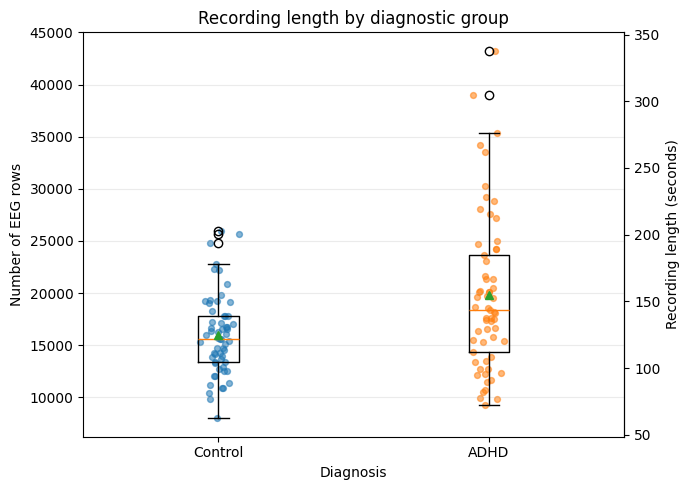

In [8]:
# Participant-level class balance
group_order = ["Control", "ADHD"]
participant_counts = (
    subject_table["Class"]
    .value_counts()
    .reindex(group_order)
    .fillna(0)
    .astype(int)
)

# ---------------- Recording length / EEG rows by diagnosis ----------------

subject_table["duration_seconds"] = (
    subject_table["number_of_rows"] / SAMPLING_RATE_HZ
)

# Summary table
length_summary = (
    subject_table
    .groupby("Class")
    .agg(
        participants=("ID", "count"),
        eeg_rows_mean=("number_of_rows", "mean"),
        eeg_rows_median=("number_of_rows", "median"),
        eeg_rows_std=("number_of_rows", "std"),
        eeg_rows_min=("number_of_rows", "min"),
        eeg_rows_max=("number_of_rows", "max"),
        duration_seconds_mean=("duration_seconds", "mean"),
        duration_seconds_median=("duration_seconds", "median"),
        duration_seconds_std=("duration_seconds", "std"),
        duration_seconds_min=("duration_seconds", "min"),
        duration_seconds_max=("duration_seconds", "max"),
    )
    .reindex(["Control", "ADHD"])
)

print("Recording-length summary by diagnostic group")
display(length_summary.round(2))


# ---------------- Boxplot ----------------

length_groups = [
    subject_table.loc[
        subject_table["Class"] == "Control",
        "number_of_rows"
    ].to_numpy(),

    subject_table.loc[
        subject_table["Class"] == "ADHD",
        "number_of_rows"
    ].to_numpy(),
]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    length_groups,
    tick_labels=["Control", "ADHD"],
    showmeans=True
)

rng = np.random.default_rng(SEED)

for x_position, values in enumerate(length_groups, start=1):
    jitter = rng.normal(0, 0.035, size=len(values))

    ax.scatter(
        np.full(len(values), x_position) + jitter,
        values,
        s=18,
        alpha=0.55,
    )

ax.set_ylabel("Number of EEG rows")
ax.set_xlabel("Diagnosis")
ax.set_title("Recording length by diagnostic group")
ax.grid(axis="y", alpha=0.25)

# Right y-axis: seconds
secax = ax.secondary_yaxis(
    "right",
    functions=(
        lambda rows: rows / SAMPLING_RATE_HZ,
        lambda seconds: seconds * SAMPLING_RATE_HZ,
    ),
)

secax.set_ylabel("Recording length (seconds)")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "recording_length_by_group.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

Participant-level EEG summary


mean_channel_sd                                                        mean_absolute_channel_mean                                                \
                  count    mean    std     min     25%     50%     75%     max                      count    mean   std     min     25%     50%     75%   
Class                                                                                                                                                     
ADHD               61.0  182.27  45.49  108.23  145.04  172.44  214.23  287.95                       61.0  139.89  7.37  112.77  138.15  141.59  143.59   
Control            60.0  230.46  85.39  115.01  170.26  215.30  257.76  524.94                       60.0  140.21  4.84  129.83  137.70  140.97  144.22   

                 
            max  
Class            
ADHD     152.65  
Control  148.03

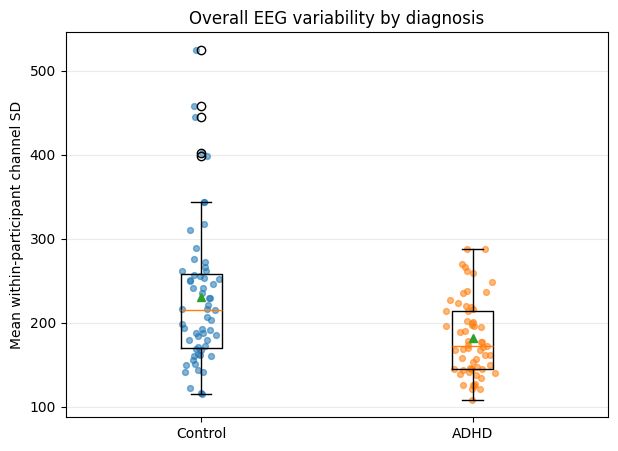

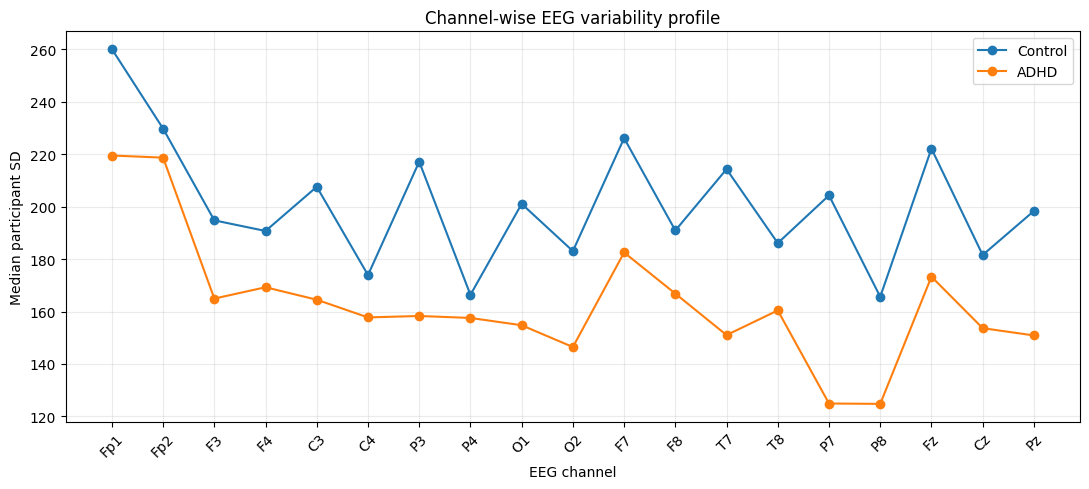

In [9]:
# -------------------- Participant-level EEG signal overview -------------------

# Compute one summary value per participant so that long recordings do not
# automatically count more than short recordings in this descriptive analysis.
participant_channel_std = data.groupby("ID")[EEG_CHANNELS].std()
participant_channel_mean = data.groupby("ID")[EEG_CHANNELS].mean()

participant_eeg_summary = pd.DataFrame({
    "ID": participant_channel_std.index,
    "mean_channel_sd": participant_channel_std.mean(axis=1).to_numpy(),
    "mean_absolute_channel_mean": participant_channel_mean.abs().mean(axis=1).to_numpy(),
})

participant_eeg_summary = participant_eeg_summary.merge(
    subject_table[["ID", "Class"]],
    on="ID",
    how="left",
)

print("Participant-level EEG summary")
display(
    participant_eeg_summary.groupby("Class")[
        ["mean_channel_sd", "mean_absolute_channel_mean"]
    ].describe().round(2)
)

# Boxplot: average within-participant EEG variability across the 19 channels
variability_groups = [
    participant_eeg_summary.loc[
        participant_eeg_summary["Class"] == cls, "mean_channel_sd"
    ].to_numpy()
    for cls in group_order
]

plt.figure(figsize=(7, 5))
plt.boxplot(variability_groups, tick_labels=group_order, showmeans=True)

rng = np.random.default_rng(SEED + 1)
for x_position, values in enumerate(variability_groups, start=1):
    jitter = rng.normal(0, 0.035, size=len(values))
    plt.scatter(
        np.full(len(values), x_position) + jitter,
        values,
        s=18,
        alpha=0.55,
    )

plt.ylabel("Mean within-participant channel SD")
plt.title("Overall EEG variability by diagnosis")
plt.grid(axis="y", alpha=0.25)
plt.show()

# Channel-wise profile. Each point is the median participant SD for that channel.
channel_std_with_class = participant_channel_std.copy()
channel_std_with_class["Class"] = (
    subject_table.set_index("ID").loc[channel_std_with_class.index, "Class"]
)

median_channel_sd = (
    channel_std_with_class.groupby("Class")[EEG_CHANNELS]
    .median()
    .reindex(group_order)
)

plt.figure(figsize=(11, 5))
for cls in group_order:
    plt.plot(
        EEG_CHANNELS,
        median_channel_sd.loc[cls].to_numpy(),
        marker="o",
        label=cls,
    )

plt.xticks(rotation=45)
plt.ylabel("Median participant SD")
plt.xlabel("EEG channel")
plt.title("Channel-wise EEG variability profile")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

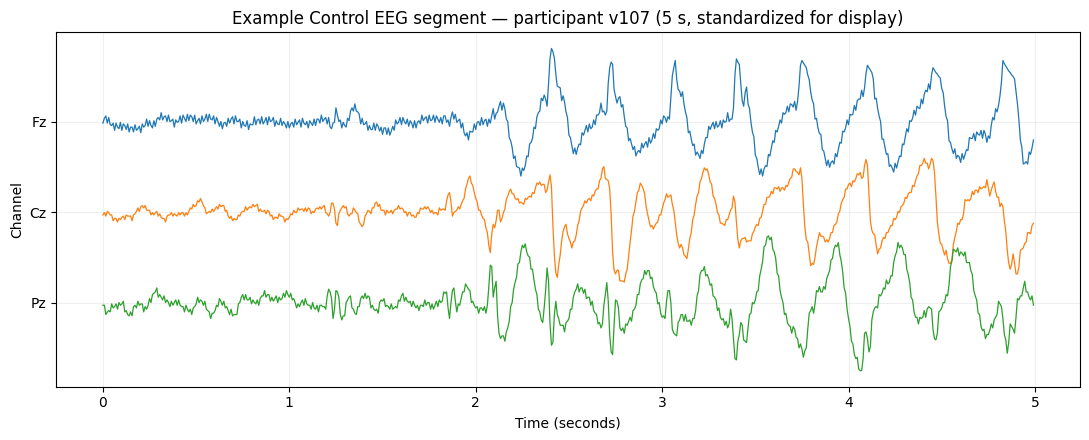

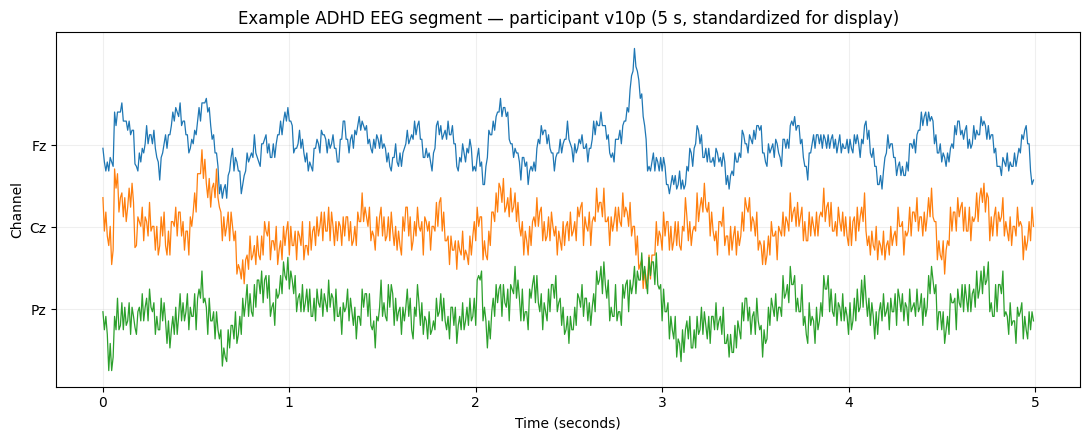

In [10]:
# ------------------------- Example raw EEG segments ---------------------------

EXAMPLE_CHANNELS = ["Fz", "Cz", "Pz"]
EXAMPLE_SECONDS = 5

def plot_example_eeg(class_name, channels=EXAMPLE_CHANNELS, seconds=EXAMPLE_SECONDS):
    subject_id = subject_table.loc[
        subject_table["Class"] == class_name, "ID"
    ].iloc[0]

    n_samples = int(seconds * SAMPLING_RATE_HZ)
    segment = (
        data.loc[data["ID"] == subject_id, channels]
        .iloc[:n_samples]
        .copy()
    )

    t = np.arange(len(segment)) / SAMPLING_RATE_HZ

    # Standardize each displayed channel only for visualization, then vertically
    # offset the traces so they do not overlap.
    standardized = (segment - segment.mean()) / (segment.std() + 1e-8)

    plt.figure(figsize=(11, 4.5))
    offsets = np.arange(len(channels))[::-1] * 4.0

    for channel, offset in zip(channels, offsets):
        plt.plot(t, standardized[channel].to_numpy() + offset, linewidth=0.9)

    plt.yticks(offsets, channels)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Channel")
    plt.title(
        f"Example {class_name} EEG segment — participant {subject_id} "
        f"({seconds} s, standardized for display)"
    )
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


plot_example_eeg("Control")
plot_example_eeg("ADHD")

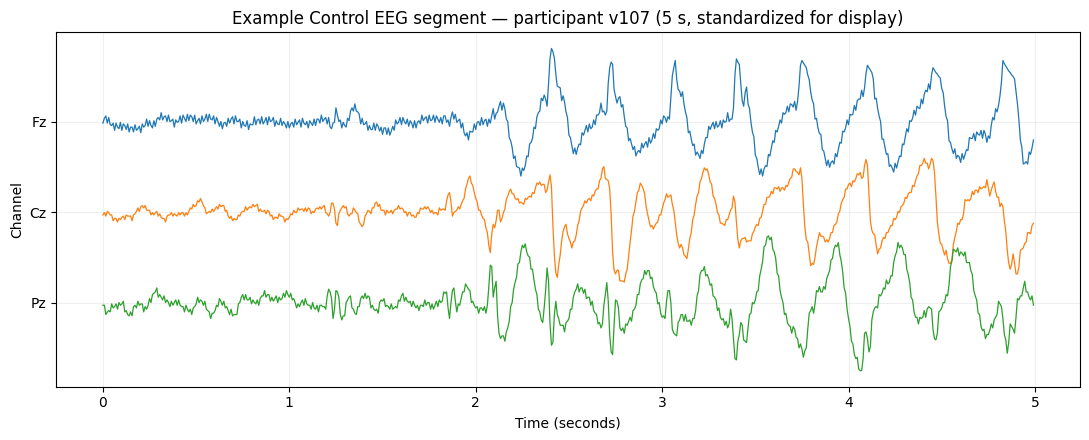

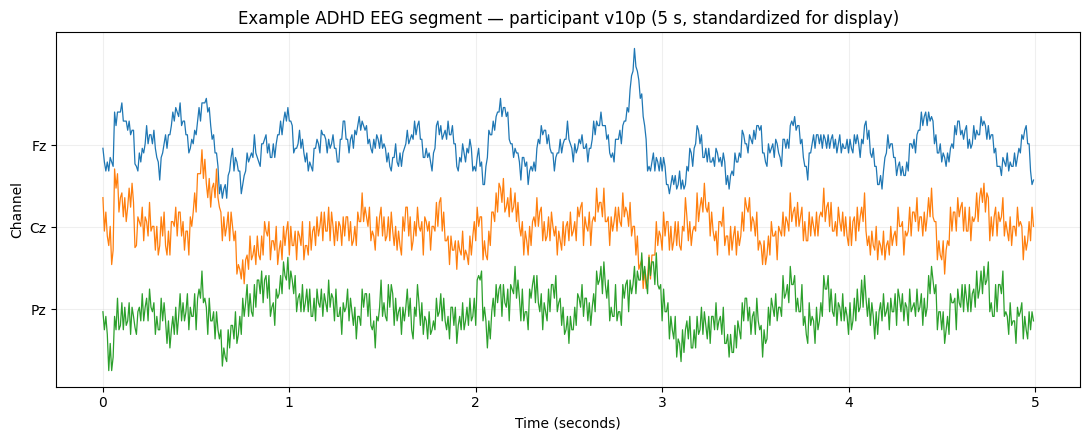

In [11]:
# ------------------------- Example raw EEG segments ---------------------------

EXAMPLE_CHANNELS = ["Fz", "Cz", "Pz"]
EXAMPLE_SECONDS = 5

def plot_example_eeg(class_name, channels=EXAMPLE_CHANNELS, seconds=EXAMPLE_SECONDS):
    subject_id = subject_table.loc[
        subject_table["Class"] == class_name, "ID"
    ].iloc[0]

    n_samples = int(seconds * SAMPLING_RATE_HZ)
    segment = (
        data.loc[data["ID"] == subject_id, channels]
        .iloc[:n_samples]
        .copy()
    )

    t = np.arange(len(segment)) / SAMPLING_RATE_HZ

    # Standardize each displayed channel only for visualization, then vertically
    # offset the traces so they do not overlap.
    standardized = (segment - segment.mean()) / (segment.std() + 1e-8)

    plt.figure(figsize=(11, 4.5))
    offsets = np.arange(len(channels))[::-1] * 4.0

    for channel, offset in zip(channels, offsets):
        plt.plot(t, standardized[channel].to_numpy() + offset, linewidth=0.9)

    plt.yticks(offsets, channels)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Channel")
    plt.title(
        f"Example {class_name} EEG segment — participant {subject_id} "
        f"({seconds} s, standardized for display)"
    )
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


plot_example_eeg("Control")
plot_example_eeg("ADHD")

## 5. Window extraction and feature engineering

Windows are selected in chronological order. If more than the configured maximum are available, starting positions are sampled evenly from the beginning to the end of the recording. This preserves broad task coverage while limiting unequal contribution from longer recordings.

For each EEG channel, the notebook extracts:

**Time-domain features**
- mean,
- standard deviation,
- minimum,
- maximum,
- median,
- RMS.

**Frequency-domain features**
- log power in delta (1–4 Hz),
- theta (4–8 Hz),
- alpha (8–13 Hz),
- beta (13–30 Hz),
- low gamma (30–40 Hz).

Finally, **relative position** ranges from 0 at the beginning to 1 near the end of the participant's recording. This retains coarse task-position information; it does **not** turn the MLP into a sequential model.

In [12]:
# Define frequency bands used for EEG power features.
FREQUENCY_BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "low_gamma": (30.0, 40.0),
}
# Define time-domain statistics extracted from each EEG window.
TIME_STATISTICS = ["mean", "std", "min", "max", "median", "rms"]

# Select chronological window starting points and cap the number of windows per
# participant.
def select_window_starts(n_rows, window_size, stride, max_windows):
    if n_rows < window_size:
        return np.empty(0, dtype=np.int64)
    starts = np.arange(0, n_rows - window_size + 1, stride, dtype=np.int64)
    if max_windows is not None and len(starts) > max_windows:
        positions = np.linspace(0, len(starts) - 1, num=max_windows, dtype=np.int64)
        starts = starts[np.unique(positions)]
    return starts

# Extract time-domain, frequency-domain and relative-position features from EEG
# windows.
def extract_all_features(windows, relative_position):
    # windows shape: [n_windows, n_channels, n_samples]
    parts = {}

    time_parts = [
        windows.mean(axis=2),
        windows.std(axis=2),
        windows.min(axis=2),
        windows.max(axis=2),
        np.median(windows, axis=2),
        np.sqrt(np.mean(np.square(windows), axis=2)),
    ]
    parts["time"] = np.concatenate(time_parts, axis=1).astype(np.float32)

    fft_values = np.fft.rfft(windows, axis=2)
    power = (np.abs(fft_values) ** 2) / windows.shape[2]
    frequencies = np.fft.rfftfreq(windows.shape[2], d=1.0 / SAMPLING_RATE_HZ)
    frequency_parts = []
    for low, high in FREQUENCY_BANDS.values():
        mask = (frequencies >= low) & (frequencies < high)
        band_power = np.log1p(power[:, :, mask].mean(axis=2))
        frequency_parts.append(band_power)
    parts["frequency"] = np.concatenate(frequency_parts, axis=1).astype(np.float32)
    parts["position"] = relative_position[:, None].astype(np.float32)
    return parts

# Create feature names corresponding to the extracted feature columns.
def make_feature_names():
    time_names = []
    for stat in TIME_STATISTICS:
        time_names.extend([f"{ch}_{stat}" for ch in EEG_CHANNELS])

    frequency_names = []
    for band in FREQUENCY_BANDS:
        frequency_names.extend([f"{ch}_{band}_logpower" for ch in EEG_CHANNELS])

    return {
        "time": time_names,
        "frequency": frequency_names,
        "position": ["relative_position"],
    }

FEATURE_NAME_GROUPS = make_feature_names()
print("Time features:", len(FEATURE_NAME_GROUPS["time"]))
print("Frequency features:", len(FEATURE_NAME_GROUPS["frequency"]))

Time features: 114
Frequency features: 95


In [13]:
time_chunks = []
frequency_chunks = []
position_chunks = []
metadata_chunks = []

start_time = time.time()

# Extract EEG windows and features separately for each participant.
for subject_number, (subject_id, subject_data) in enumerate(data.groupby("ID", sort=False), start=1):
    class_name = subject_data["Class"].iloc[0]
    label = LABEL_MAPPING[class_name]
    values = subject_data[EEG_CHANNELS].to_numpy(dtype=np.float32, copy=False)

    starts = select_window_starts(
        len(values), WINDOW_SIZE, WINDOW_STRIDE, MAX_WINDOWS_PER_SUBJECT
    )
    if len(starts) == 0:
        print(f"Skipping {subject_id}: fewer than {WINDOW_SIZE} rows")
        continue

    windows = np.stack([values[s:s + WINDOW_SIZE].T for s in starts]).astype(np.float32)
    denominator = max(len(values) - WINDOW_SIZE, 1)
    relative_position = (starts / denominator).astype(np.float32)
    features = extract_all_features(windows, relative_position)

    time_chunks.append(features["time"])
    frequency_chunks.append(features["frequency"])
    position_chunks.append(features["position"])
    metadata_chunks.append(pd.DataFrame({
        "ID": subject_id,
        "Class": class_name,
        "label": label,
        "window_start": starts,
        "relative_position": relative_position,
    }))

    if subject_number % 20 == 0:
        print(f"Processed {subject_number}/{len(subject_table)} participants")

# Combine features from all participants into participant-associated
# window-level matrices.
X_time = np.concatenate(time_chunks, axis=0)
X_frequency = np.concatenate(frequency_chunks, axis=0)
X_position = np.concatenate(position_chunks, axis=0)
window_metadata = pd.concat(metadata_chunks, ignore_index=True)

# Release the original data table after feature extraction to reduce memory
# usage.
del time_chunks, frequency_chunks, position_chunks, metadata_chunks, data

assert len(X_time) == len(X_frequency) == len(X_position) == len(window_metadata)

# Define feature sets for comparing time, frequency and position information.
FEATURE_SETS = {
    "time_only": X_time,
    "frequency_only": X_frequency,
    "time_frequency": np.concatenate([X_time, X_frequency], axis=1),
    "time_frequency_position": np.concatenate([X_time, X_frequency, X_position], axis=1),
}

print(f"Windows: {len(window_metadata):,}")
for name, matrix in FEATURE_SETS.items():
    print(name, matrix.shape)
print(f"Extraction time: {(time.time() - start_time) / 60:.1f} minutes")

display(window_metadata.groupby(["Class", "ID"]).size().groupby(level=0).describe())

Processed 20/121 participants
Processed 40/121 participants
Processed 60/121 participants
Processed 80/121 participants
Processed 100/121 participants
Processed 120/121 participants
Windows: 7,625
time_only (7625, 114)
frequency_only (7625, 95)
time_frequency (7625, 209)
time_frequency_position (7625, 210)
Extraction time: 0.0 minutes


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
ADHD,61.0,66.245902,14.579273,35.0,54.0,70.0,80.0,80.0
Control,60.0,59.733333,12.531813,30.0,51.0,59.5,68.0,80.0


## 6. Why participant-level weighting is used

Even after capping the number of windows, some shorter recordings may contribute fewer windows. During MLP training, each window receives a weight inversely proportional to the number of training windows from that participant. Thus, every participant contributes approximately the same total weight to the loss.

In [14]:
# Assign weights so that each participant contributes equally to the training loss.
def participant_equal_weights(subject_ids):
    subject_ids = np.asarray(subject_ids)
    unique_ids, counts = np.unique(subject_ids, return_counts=True)
    count_map = dict(zip(unique_ids, counts))
    weights = np.array([1.0 / count_map[sid] for sid in subject_ids], dtype=np.float32)
    return weights / weights.mean()

# Aggregate window-level predictions into one prediction per participant.
def aggregate_participant_predictions(metadata_subset, probabilities, threshold=0.5):
    frame = metadata_subset[["ID", "Class", "label"]].copy()
    frame["probability_adhd"] = np.asarray(probabilities)
    participant = (
        frame.groupby("ID", sort=False)
        .agg(
            Class=("Class", "first"),
            label=("label", "first"),
            probability_adhd=("probability_adhd", "mean"),
            number_of_windows=("probability_adhd", "size"),
        )
        .reset_index()
    )
    participant["prediction"] = (participant["probability_adhd"] >= threshold).astype(int)
    return participant

# Calculate classification metrics from participant-level predictions.
def classification_metrics(y_true, probability, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    probability = np.asarray(probability)
    prediction = (probability >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability) if len(np.unique(y_true)) == 2 else np.nan,
    }

# Calculate binary cross-entropy with optional sample weighting.
def weighted_binary_cross_entropy(y_true, probabilities, sample_weights=None):
    y_true = np.asarray(y_true, dtype=np.float32)
    p = np.clip(np.asarray(probabilities), 1e-7, 1 - 1e-7)
    loss = -(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
    if sample_weights is None:
        return float(loss.mean())
    w = np.asarray(sample_weights, dtype=np.float32)
    return float(np.sum(loss * w) / np.sum(w))

## 7. Feedforward MLP implemented from scratch in NumPy

This is the **required neural-network model** for the project. The forward pass, ReLU and sigmoid activations, backpropagation, Adam updates and L2 weight regularization are implemented directly with NumPy.

The architecture is deliberately compact: **input → 64 → 32 → 1**, given the limited number of independent participants (n = 121).

In [15]:
class NumpyMLP:
    """Binary feedforward neural network implemented from scratch with NumPy."""

    def __init__(self, input_size, hidden_layers=(64, 32), learning_rate=5e-4, l2=1e-3, random_state=42):
        self.hidden_layers = tuple(hidden_layers)
        self.learning_rate = float(learning_rate)
        self.l2 = float(l2)
        self.random_state = int(random_state)

        rng = np.random.default_rng(self.random_state)
        layer_sizes = [input_size, *self.hidden_layers, 1]
        self.number_of_layers = len(layer_sizes) - 1
        self.parameters, self.adam_m, self.adam_v = {}, {}, {}
        self.adam_step = 0

        for layer in range(1, self.number_of_layers + 1):
            fan_in, fan_out = layer_sizes[layer - 1], layer_sizes[layer]
            scale = np.sqrt(2.0 / fan_in) if layer < self.number_of_layers else np.sqrt(1.0 / fan_in)
            W, b = f"W{layer}", f"b{layer}"
            self.parameters[W] = (rng.standard_normal((fan_in, fan_out)) * scale).astype(np.float32)
            self.parameters[b] = np.zeros((1, fan_out), dtype=np.float32)
            self.adam_m[W] = np.zeros_like(self.parameters[W]); self.adam_m[b] = np.zeros_like(self.parameters[b])
            self.adam_v[W] = np.zeros_like(self.parameters[W]); self.adam_v[b] = np.zeros_like(self.parameters[b])

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -30, 30)
        return 1.0 / (1.0 + np.exp(-z))

    def forward(self, X):
        activations = [X]
        preactivations = []
        current = X
        for layer in range(1, self.number_of_layers):
            z = current @ self.parameters[f"W{layer}"] + self.parameters[f"b{layer}"]
            preactivations.append(z)
            current = np.maximum(z, 0.0)
            activations.append(current)
        last = self.number_of_layers
        z = current @ self.parameters[f"W{last}"] + self.parameters[f"b{last}"]
        p = self._sigmoid(z)
        preactivations.append(z)
        activations.append(p)
        return p, activations, preactivations

    def predict_proba(self, X):
        return self.forward(X)[0].ravel()

    def train_batch(self, X, y, sample_weights=None):
        y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
        if sample_weights is None:
            w = np.ones((len(X), 1), dtype=np.float32)
        else:
            w = np.asarray(sample_weights, dtype=np.float32).reshape(-1, 1)
        w = w / np.sum(w)

        p, activations, preactivations = self.forward(X)
        gradients = {}
        dz = (p - y) * w

        for layer in range(self.number_of_layers, 0, -1):
            prev = activations[layer - 1]
            W, b = f"W{layer}", f"b{layer}"
            gradients[W] = prev.T @ dz + self.l2 * self.parameters[W]
            gradients[b] = dz.sum(axis=0, keepdims=True)
            if layer > 1:
                da = dz @ self.parameters[W].T
                dz = da * (preactivations[layer - 2] > 0)
        self._adam_update(gradients)

    def _adam_update(self, gradients, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.adam_step += 1
        for key, grad in gradients.items():
            self.adam_m[key] = beta1 * self.adam_m[key] + (1 - beta1) * grad
            self.adam_v[key] = beta2 * self.adam_v[key] + (1 - beta2) * np.square(grad)
            m_hat = self.adam_m[key] / (1 - beta1 ** self.adam_step)
            v_hat = self.adam_v[key] / (1 - beta2 ** self.adam_step)
            self.parameters[key] -= self.learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

    def get_state(self):
        return {k: v.copy() for k, v in self.parameters.items()}

    def set_state(self, state):
        self.parameters = {k: v.copy() for k, v in state.items()}

In [16]:
def train_with_early_stopping(
    X_train, y_train, train_ids,
    X_validation, y_validation, validation_metadata,
    config, max_epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    patience=EARLY_STOPPING_PATIENCE, seed=SEED,
):
    """Train the MLP with participant-weighted loss and participant-level validation for early stopping."""
    model = NumpyMLP(input_size=X_train.shape[1], random_state=seed, **config)
    rng = np.random.default_rng(seed)
    train_weights = participant_equal_weights(train_ids)

    best_state = model.get_state()
    best_epoch = 1
    best_f1 = -np.inf
    best_val_loss = np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        order = rng.permutation(len(X_train))
        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            model.train_batch(X_train[idx], y_train[idx], train_weights[idx])

        train_p = model.predict_proba(X_train)
        val_p = model.predict_proba(X_validation)
        train_loss = weighted_binary_cross_entropy(y_train, train_p, train_weights)
        val_loss = weighted_binary_cross_entropy(y_validation, val_p)

        val_participants = aggregate_participant_predictions(validation_metadata, val_p)
        val_f1 = f1_score(val_participants["label"], val_participants["prediction"], zero_division=0)
        val_auc = roc_auc_score(val_participants["label"], val_participants["probability_adhd"])
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": val_loss,
            "validation_participant_f1": val_f1,
            "validation_participant_auc": val_auc,
        })

        # Primary epoch-selection criterion: participant-level validation F1.
        # Validation loss breaks ties and the outer fold remains untouched.
        improved = (val_f1 > best_f1 + 1e-9) or (
            abs(val_f1 - best_f1) <= 1e-9 and val_loss < best_val_loss - 1e-5
        )
        if improved:
            best_state = model.get_state()
            best_epoch = epoch
            best_f1 = val_f1
            best_val_loss = val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            break

    model.set_state(best_state)
    return model, pd.DataFrame(history), best_epoch


def fit_fixed_epochs(X, y, subject_ids, config, epochs, seed=SEED, batch_size=BATCH_SIZE):
    """Train the MLP for a fixed number of epochs using participant-equal sample weights."""

    model = NumpyMLP(input_size=X.shape[1], random_state=seed, **config)
    rng = np.random.default_rng(seed)
    weights = participant_equal_weights(subject_ids)
    for _ in range(int(epochs)):
        order = rng.permutation(len(X))
        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            model.train_batch(X[idx], y[idx], weights[idx])
    return model

## 8. Participant-level 5-fold cross-validation and feature ablation

The outer fold provides the final performance estimate. Within each outer-training set, participants are further split into inner training and validation sets. The inner validation set is used to select the training epochs. The selected model is then reinitialized and retrained on all outer-training participants before predicting the untouched outer fold.

This avoids using the outer test fold for preprocessing or early stopping.

### Experiments

- **Logistic baseline:** time + frequency.
- **MLP time only:** tests whether simple amplitude/variability summaries are informative.
- **MLP frequency only:** tests whether spectral information alone is informative.
- **MLP time + frequency:** main model; tests whether the two representations are complementary.
- **MLP time + frequency + position:** tests whether coarse task position adds anything further.

In [17]:
participant_labels = (
    window_metadata[["ID", "Class", "label"]]
    .drop_duplicates("ID")
    .reset_index(drop=True)
)

outer_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

EXPERIMENTS = {
    "mlp_time": "time_only",
    "mlp_frequency": "frequency_only",
    "mlp_time_frequency": "time_frequency",
    "mlp_time_frequency_position": "time_frequency_position",
}

fold_metric_rows = []
oof_frames = []
epoch_rows = []
history_rows = []


for fold, (outer_train_subject_rows, outer_test_subject_rows) in enumerate(
    outer_cv.split(participant_labels["ID"], participant_labels["label"]), start=1
):
    print("\n" + "=" * 78)
    print(f"OUTER FOLD {fold}/{N_SPLITS}")
    print("=" * 78)

    outer_train_subjects = participant_labels.iloc[outer_train_subject_rows].copy()
    outer_test_subjects = participant_labels.iloc[outer_test_subject_rows].copy()
    outer_train_ids = set(outer_train_subjects["ID"])
    outer_test_ids = set(outer_test_subjects["ID"])
    assert outer_train_ids.isdisjoint(outer_test_ids)

    outer_train_idx = np.flatnonzero(window_metadata["ID"].isin(outer_train_ids).to_numpy())
    outer_test_idx = np.flatnonzero(window_metadata["ID"].isin(outer_test_ids).to_numpy())

    inner_train_subjects, inner_val_subjects = train_test_split(
        outer_train_subjects,
        test_size=INNER_VALIDATION_FRACTION,
        random_state=SEED + fold,
        stratify=outer_train_subjects["label"],
    )
    inner_train_ids = set(inner_train_subjects["ID"])
    inner_val_ids = set(inner_val_subjects["ID"])
    inner_train_idx = np.flatnonzero(window_metadata["ID"].isin(inner_train_ids).to_numpy())
    inner_val_idx = np.flatnonzero(window_metadata["ID"].isin(inner_val_ids).to_numpy())

    fold_participant_predictions = outer_test_subjects[["ID", "Class", "label"]].copy().reset_index(drop=True)

    # ---------- Logistic-regression baseline on all engineered features ----------
    X_all = FEATURE_SETS["time_frequency"]
    baseline_scaler = StandardScaler()
    Xtr = baseline_scaler.fit_transform(X_all[outer_train_idx]).astype(np.float32)
    Xte = baseline_scaler.transform(X_all[outer_test_idx]).astype(np.float32)
    baseline = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED + fold)
    baseline.fit(Xtr, window_metadata.iloc[outer_train_idx]["label"].to_numpy())
    baseline_window_p = baseline.predict_proba(Xte)[:, 1]
    baseline_participant = aggregate_participant_predictions(
        window_metadata.iloc[outer_test_idx].reset_index(drop=True), baseline_window_p
    )
    baseline_metrics = classification_metrics(
        baseline_participant["label"], baseline_participant["probability_adhd"]
    )
    fold_metric_rows.append({"fold": fold, "model": "logistic_baseline", **baseline_metrics})
    fold_participant_predictions = fold_participant_predictions.merge(
        baseline_participant[["ID", "probability_adhd"]].rename(columns={"probability_adhd":"logistic_baseline_probability"}),
        on="ID", how="left"
    )

    # ---------- NumPy-MLP experiments ----------
    for model_name, feature_set_name in EXPERIMENTS.items():
        X = FEATURE_SETS[feature_set_name]

        # Inner preprocessing for epoch selection.
        inner_scaler = StandardScaler()
        Xin_train = inner_scaler.fit_transform(X[inner_train_idx]).astype(np.float32)
        Xin_val = inner_scaler.transform(X[inner_val_idx]).astype(np.float32)
        y_in_train = window_metadata.iloc[inner_train_idx]["label"].to_numpy(np.int64)
        y_in_val = window_metadata.iloc[inner_val_idx]["label"].to_numpy(np.int64)
        ids_in_train = window_metadata.iloc[inner_train_idx]["ID"].to_numpy()
        inner_val_metadata = window_metadata.iloc[inner_val_idx].reset_index(drop=True)

        _, history, best_epoch = train_with_early_stopping(
            Xin_train, y_in_train, ids_in_train,
            Xin_val, y_in_val, inner_val_metadata,
            config=MLP_CONFIG,
            seed=SEED + fold * 100 + list(EXPERIMENTS).index(model_name),
        )
        history["fold"] = fold
        history["model"] = model_name
        history_rows.append(history)
        epoch_rows.append({"fold": fold, "model": model_name, "selected_epochs": best_epoch})

        # Refit scaler and MLP on all outer-training participants.
        outer_scaler = StandardScaler()
        X_outer_train = outer_scaler.fit_transform(X[outer_train_idx]).astype(np.float32)
        X_outer_test = outer_scaler.transform(X[outer_test_idx]).astype(np.float32)
        y_outer_train = window_metadata.iloc[outer_train_idx]["label"].to_numpy(np.int64)
        outer_train_window_ids = window_metadata.iloc[outer_train_idx]["ID"].to_numpy()

        model = fit_fixed_epochs(
            X_outer_train,
            y_outer_train,
            outer_train_window_ids,
            config=MLP_CONFIG,
            epochs=best_epoch,
            seed=SEED + fold * 1000 + list(EXPERIMENTS).index(model_name),
        )
        window_probability = model.predict_proba(X_outer_test)
        participant_prediction = aggregate_participant_predictions(
            window_metadata.iloc[outer_test_idx].reset_index(drop=True), window_probability
        )
        metrics = classification_metrics(
            participant_prediction["label"], participant_prediction["probability_adhd"]
        )
        fold_metric_rows.append({"fold": fold, "model": model_name, **metrics})
        fold_participant_predictions = fold_participant_predictions.merge(
            participant_prediction[["ID", "probability_adhd"]].rename(
                columns={"probability_adhd": f"{model_name}_probability"}
            ),
            on="ID", how="left"
        )
        print(
            model_name,
            "epochs=",
            best_epoch,
            {k: round(v, 3) for k, v in metrics.items()}
        )

    fold_participant_predictions.insert(0, "fold", fold)
    oof_frames.append(fold_participant_predictions)

fold_metrics = pd.DataFrame(fold_metric_rows)
oof_participant_predictions = pd.concat(oof_frames, ignore_index=True)
epoch_selection = pd.DataFrame(epoch_rows)
training_history = pd.concat(history_rows, ignore_index=True)

assert oof_participant_predictions["ID"].nunique() == participant_labels["ID"].nunique()
print("\nFinished cross-validation.")


OUTER FOLD 1/5
mlp_time epochs= 9 {'accuracy': 0.64, 'balanced_accuracy': np.float64(0.631), 'precision': 0.611, 'recall': 0.846, 'f1': 0.71, 'roc_auc': np.float64(0.705)}
mlp_frequency epochs= 6 {'accuracy': 0.6, 'balanced_accuracy': np.float64(0.596), 'precision': 0.6, 'recall': 0.692, 'f1': 0.643, 'roc_auc': np.float64(0.59)}
mlp_time_frequency epochs= 5 {'accuracy': 0.76, 'balanced_accuracy': np.float64(0.756), 'precision': 0.733, 'recall': 0.846, 'f1': 0.786, 'roc_auc': np.float64(0.769)}
mlp_time_frequency_position epochs= 7 {'accuracy': 0.64, 'balanced_accuracy': np.float64(0.631), 'precision': 0.611, 'recall': 0.846, 'f1': 0.71, 'roc_auc': np.float64(0.769)}

OUTER FOLD 2/5
mlp_time epochs= 4 {'accuracy': 0.792, 'balanced_accuracy': np.float64(0.792), 'precision': 0.769, 'recall': 0.833, 'f1': 0.8, 'roc_auc': np.float64(0.875)}
mlp_frequency epochs= 3 {'accuracy': 0.75, 'balanced_accuracy': np.float64(0.75), 'precision': 0.75, 'recall': 0.75, 'f1': 0.75, 'roc_auc': np.float64(

## 9. Main results

The **pooled out-of-fold** metrics use one participant-level prediction for each child, generated by a model that did not train on that child. Fold mean ± standard deviation shows sensitivity to the participant split.

The main model is `mlp_time_frequency`. The additional feature configurations are interpreted as feature ablations rather than as separate model-development searches.

In [18]:
metric_columns = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]
cv_summary = fold_metrics.groupby("model")[metric_columns].agg(["mean", "std"])
print("Fold-level mean ± SD")
display(cv_summary.round(3))

pooled_rows = []
model_names = ["logistic_baseline", *EXPERIMENTS.keys()]
y_true = oof_participant_predictions["label"].to_numpy()

for model_name in model_names:
    p = oof_participant_predictions[f"{model_name}_probability"].to_numpy()
    pooled_rows.append({"model": model_name, **classification_metrics(y_true, p)})

pooled_metrics = pd.DataFrame(pooled_rows)
print("Pooled participant-level out-of-fold metrics")
display(pooled_metrics.round(3))

# Save cross-validation results and out-of-fold predictions for reporting.
fold_metrics.to_csv(OUTPUT_DIR / "fold_metrics.csv", index=False)
pooled_metrics.to_csv(OUTPUT_DIR / "pooled_metrics.csv", index=False)
oof_participant_predictions.to_csv(OUTPUT_DIR / "oof_participant_predictions.csv", index=False)
epoch_selection.to_csv(OUTPUT_DIR / "selected_epochs.csv", index=False)
training_history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

Fold-level mean ± SD


accuracy        balanced_accuracy        precision        recall            f1        roc_auc       
                                mean    std              mean    std      mean    std   mean    std   mean    std    mean    std
model                                                                                                                           
logistic_baseline              0.712  0.083             0.710  0.085     0.738  0.119  0.704  0.051  0.715  0.054   0.806  0.091
mlp_frequency                  0.637  0.078             0.636  0.078     0.635  0.075  0.655  0.110  0.643  0.086   0.658  0.062
mlp_time                       0.728  0.071             0.726  0.074     0.708  0.076  0.803  0.048  0.750  0.050   0.799  0.094
mlp_time_frequency             0.769  0.108             0.768  0.108     0.766  0.143  0.803  0.096  0.780  0.102   0.826  0.065
mlp_time_frequency_position    0.736  0.070             0.735  0.073     0.759  0.102  0.736  0.112  0.738  0.058   0.822  0.078

Pooled participant-level out-of-fold metrics


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,logistic_baseline,0.711,0.711,0.717,0.705,0.711,0.796
1,mlp_time,0.727,0.727,0.700,0.803,0.748,0.793
2,mlp_frequency,0.636,0.636,0.635,0.656,0.645,0.659
3,mlp_time_frequency,0.769,0.768,0.754,0.803,0.778,0.832
4,mlp_time_frequency_position,0.736,0.736,0.738,0.738,0.738,0.810


## 10. Learning behavior and early stopping

The assignment asks for insight into **learning behavior** as well as final evaluation metrics. During the inner validation stage, the notebook records training loss, validation loss, validation participant-level F1 and validation ROC-AUC for every epoch.

The figure below shows these curves for the prespecified main feature set (`time + frequency`) in each outer fold. The outer test fold is used only for the final evaluation and is never used for epoch selection. Different folds may stop at different epochs because the inner validation participants differ.

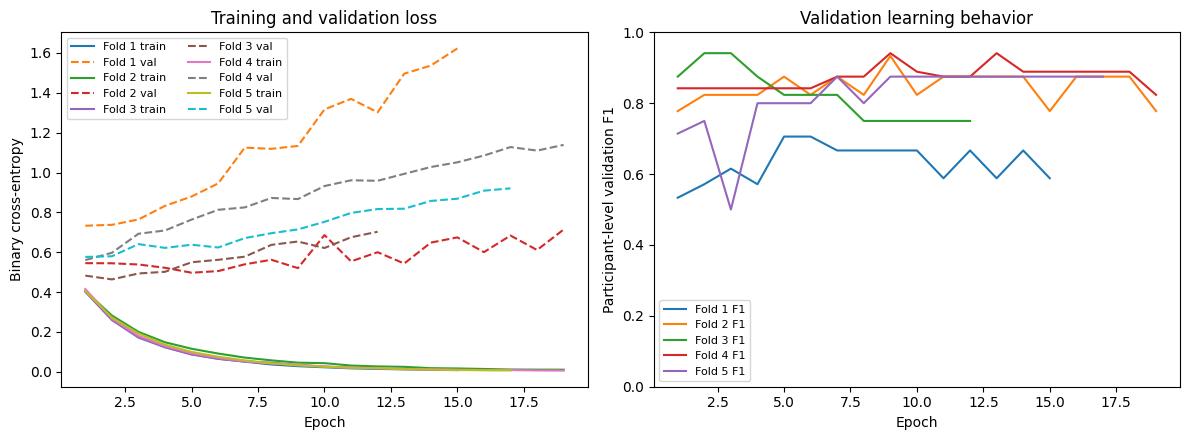

,fold,model,selected_epochs
0,1,mlp_time_frequency,5
1,2,mlp_time_frequency,9
2,3,mlp_time_frequency,2
3,4,mlp_time_frequency,9
4,5,mlp_time_frequency,7


In [19]:
# Learning curves for the prespecified main MLP across the inner validation runs.
main_history = training_history[training_history["model"] == "mlp_time_frequency"].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for fold in sorted(main_history["fold"].unique()):
    fold_history = main_history[main_history["fold"] == fold]
    axes[0].plot(fold_history["epoch"], fold_history["train_loss"], label=f"Fold {fold} train")
    axes[0].plot(fold_history["epoch"], fold_history["validation_loss"], linestyle="--", label=f"Fold {fold} val")
    axes[1].plot(fold_history["epoch"], fold_history["validation_participant_f1"], label=f"Fold {fold} F1")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].set_title("Training and validation loss")
axes[0].legend(fontsize=8, ncol=2)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Participant-level validation F1")
axes[1].set_ylim(0, 1)
axes[1].set_title("Validation learning behavior")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "main_mlp_learning_curves.png", dpi=160, bbox_inches="tight")
plt.show()

display(
    epoch_selection[epoch_selection["model"] == "mlp_time_frequency"]
    .sort_values("fold")
    .reset_index(drop=True)
)


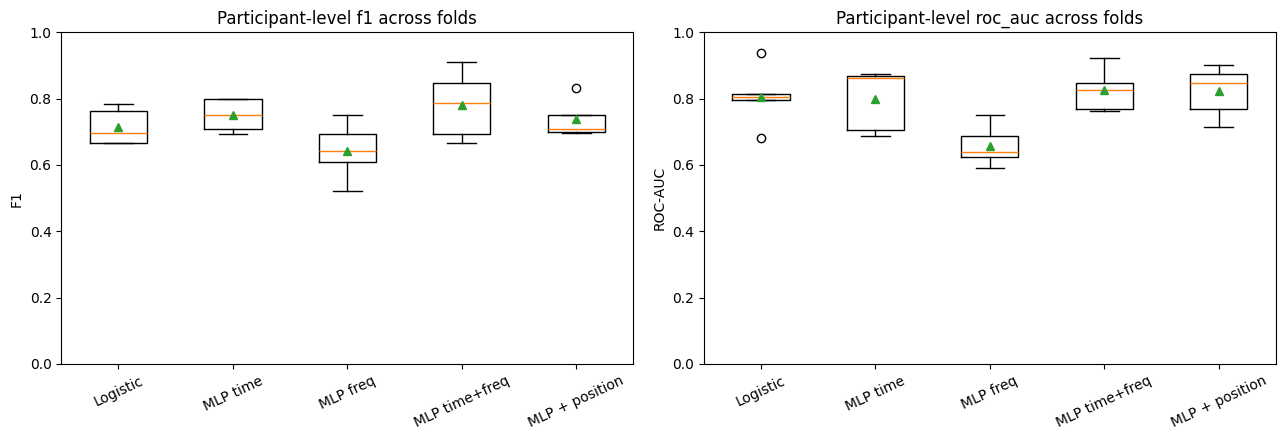

In [20]:
# Compact model-comparison figure: participant-level F1 and ROC-AUC across folds.
models = ["logistic_baseline", "mlp_time", "mlp_frequency", "mlp_time_frequency", "mlp_time_frequency_position"]
labels = ["Logistic", "MLP time", "MLP freq", "MLP time+freq", "MLP + position"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ["f1", "roc_auc"]):
    values = [fold_metrics.loc[fold_metrics["model"] == m, metric] for m in models]
    ax.boxplot(values, tick_labels=labels, showmeans=True)
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric.upper() if metric == "f1" else "ROC-AUC")
    ax.set_title(f"Participant-level {metric} across folds")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_cv.png", dpi=160, bbox_inches="tight")
plt.show()

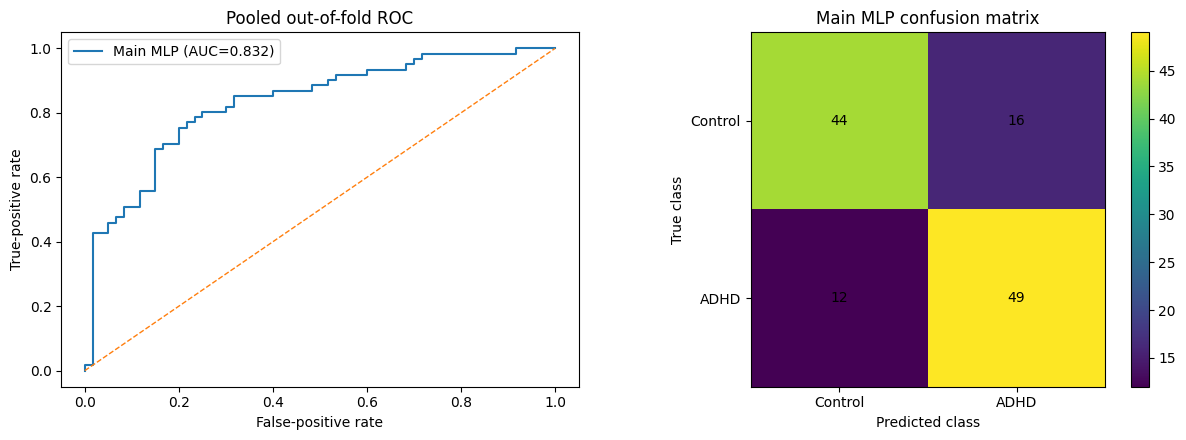

In [21]:
# ROC curve and confusion matrix for the selected main MLP.

MAIN_MODEL = "mlp_time_frequency"

main_probability = oof_participant_predictions[
    f"{MAIN_MODEL}_probability"
].to_numpy()

main_prediction = (main_probability >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

fpr, tpr, _ = roc_curve(y_true, main_probability)
auc = roc_auc_score(y_true, main_probability)

axes[0].plot(fpr, tpr, label=f"Main MLP (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].set_title("Pooled out-of-fold ROC")
axes[0].legend()

cm = confusion_matrix(y_true, main_prediction, labels=[0, 1])

image = axes[1].imshow(cm)
axes[1].set_xticks([0, 1], ["Control", "ADHD"])
axes[1].set_yticks([0, 1], ["Control", "ADHD"])
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("True class")
axes[1].set_title("Main MLP confusion matrix")

for row in range(2):
    for col in range(2):
        axes[1].text(
            col,
            row,
            cm[row, col],
            ha="center",
            va="center"
        )

plt.colorbar(image, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "main_mlp_roc_confusion.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

## 11. What did frequency features and relative position add?

The ablation table below is the scientific core of the project. Compare the pooled participant-level metrics of the four MLP variants.

- `mlp_time` vs `mlp_time_frequency` evaluates whether frequency-domain features add information to the time-domain representation.
- `mlp_frequency` evaluates whether frequency-domain features are informative on their own.
- `mlp_time_frequency_position` asks whether coarse location within the task adds further information beyond the time + frequency representation.

The comparisons focus on the contribution of feature representations rather than on finding the highest possible classification performance.

In [25]:
# Compare the four MLP feature sets at participant level.
ablation_table = pooled_metrics[
    pooled_metrics["model"].isin(EXPERIMENTS.keys())
].copy()

reference_row = ablation_table.loc[
    ablation_table["model"] == "mlp_time"
].iloc[0]

main_row = ablation_table.loc[
    ablation_table["model"] == "mlp_time_frequency"
].iloc[0]

ablation_table["delta_f1_vs_time"] = (
    ablation_table["f1"] - reference_row["f1"]
)

ablation_table["delta_auc_vs_time"] = (
    ablation_table["roc_auc"] - reference_row["roc_auc"]
)

ablation_table["delta_f1_vs_time_frequency"] = (
    ablation_table["f1"] - main_row["f1"]
)

ablation_table["delta_auc_vs_time_frequency"] = (
    ablation_table["roc_auc"] - main_row["roc_auc"]
)

display(ablation_table[
    [
        "model",
        "f1",
        "roc_auc",
        "delta_f1_vs_time",
        "delta_auc_vs_time",
        "delta_f1_vs_time_frequency",
        "delta_auc_vs_time_frequency",
    ]
].round(3))

,model,f1,roc_auc,delta_f1_vs_time,delta_auc_vs_time,delta_f1_vs_time_frequency,delta_auc_vs_time_frequency
1,mlp_time,0.748,0.793,0.000,0.000,-0.030,-0.039
2,mlp_frequency,0.645,0.659,-0.103,-0.134,-0.133,-0.173
3,mlp_time_frequency,0.778,0.832,0.030,0.039,0.000,0.000
4,mlp_time_frequency_position,0.738,0.810,-0.010,0.017,-0.040,-0.022


## 12. Optional exploratory channel analysis

Participant-level feature averages were compared between diagnostic groups using Cohen's d. This analysis is descriptive and exploratory. It does **not** establish causality, clinical diagnostic value or independence from medication and task-performance confounds.

,channel,abs_d
14,P7,0.552
17,T7,0.437
16,Pz,0.414
12,P3,0.400
9,Fz,0.395
0,C3,0.363
3,F3,0.363
10,O1,0.335
5,F7,0.322
2,Cz,0.294


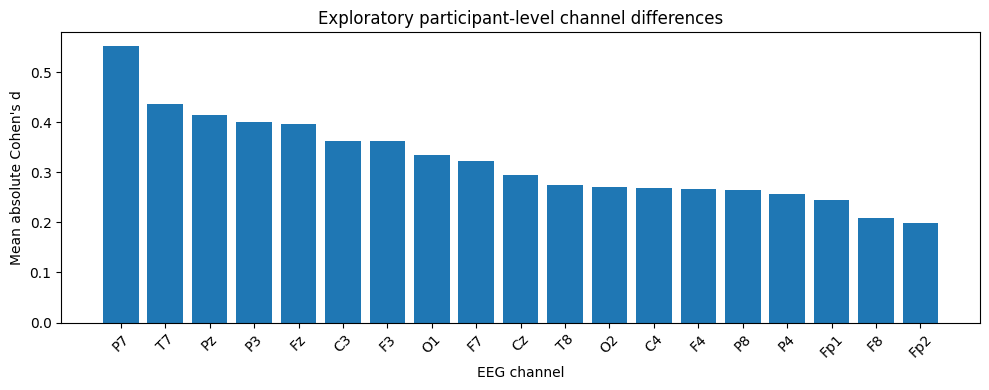

In [23]:
# Use time + frequency features, but exclude relative position from channel effect-size ranking.
all_feature_matrix = FEATURE_SETS["time_frequency"]
all_feature_names = FEATURE_NAME_GROUPS["time"] + FEATURE_NAME_GROUPS["frequency"]
feature_frame = pd.DataFrame(all_feature_matrix, columns=all_feature_names)
feature_frame[["ID", "Class"]] = window_metadata[["ID", "Class"]].reset_index(drop=True)
participant_features = feature_frame.groupby(["ID", "Class"], observed=True)[all_feature_names].mean().reset_index()


def cohens_d(a, b):
    """Calculate Cohen's d for two independent groups."""
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    va, vb = a.var(ddof=1), b.var(ddof=1)
    pooled = (((len(a)-1)*va + (len(b)-1)*vb) / (len(a)+len(b)-2))
    return 0.0 if pooled <= 0 else (a.mean() - b.mean()) / np.sqrt(pooled)

rows = []
for feature in all_feature_names:
    a = participant_features.loc[participant_features["Class"] == "ADHD", feature]
    b = participant_features.loc[participant_features["Class"] == "Control", feature]
    channel = feature.split("_")[0]
    rows.append({"feature": feature, "channel": channel, "cohens_d_adhd_minus_control": cohens_d(a, b)})

feature_effect_sizes = pd.DataFrame(rows)
channel_effect_sizes = (
    feature_effect_sizes.assign(abs_d=feature_effect_sizes["cohens_d_adhd_minus_control"].abs())
    .groupby("channel", as_index=False)["abs_d"].mean()
    .sort_values("abs_d", ascending=False)
)
display(channel_effect_sizes.round(3))

plt.figure(figsize=(10, 4))
plt.bar(channel_effect_sizes["channel"], channel_effect_sizes["abs_d"])
plt.xlabel("EEG channel")
plt.ylabel("Mean absolute Cohen's d")
plt.title("Exploratory participant-level channel differences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exploratory_channel_effect_sizes.png", dpi=160, bbox_inches="tight")
plt.show()

## 13. Report-ready result summary

**OFFEN:** Run this cell only after the full cross-validation has finished. Copy the generated values into the report, but keep the wording cautious and participant-level.

In [24]:
main = pooled_metrics.loc[pooled_metrics["model"] == "mlp_time_frequency"].iloc[0]
base = pooled_metrics.loc[pooled_metrics["model"] == "logistic_baseline"].iloc[0]
length = length_confound_metrics

summary_text = f"""
The dataset contained {len(subject_table)} participants ({(subject_table['Class']=='ADHD').sum()} ADHD and {(subject_table['Class']=='Control').sum()} controls).
Recording duration varied between participants and depended on task response speed, so recording length was treated as a potential behavioral confound rather than an EEG feature. A recording-length-only cross-validated logistic model achieved ROC-AUC {length['roc_auc']:.3f}.

Using participant-stratified {N_SPLITS}-fold cross-validation, the main NumPy MLP using time-domain and frequency-domain achieved pooled out-of-fold participant-level accuracy {main['accuracy']:.3f}, F1 {main['f1']:.3f}, and ROC-AUC {main['roc_auc']:.3f}. The logistic-regression baseline achieved accuracy {base['accuracy']:.3f}, F1 {base['f1']:.3f}, and ROC-AUC {base['roc_auc']:.3f}.

The ablation analysis should be used to determine whether spectral features and coarse task-position information added measurable discriminative value. All results describe internal cross-validated generalization within this dataset and should not be interpreted as clinical diagnostic performance.
""".strip()

print(summary_text)
(OUTPUT_DIR / "report_ready_summary.txt").write_text(summary_text + "\n", encoding="utf-8")

The dataset contained 121 participants (61 ADHD and 60 controls).
Recording duration varied between participants and depended on task response speed, so recording length was treated as a potential behavioral confound rather than an EEG feature. A recording-length-only cross-validated logistic model achieved ROC-AUC 0.655.

Using participant-stratified 5-fold cross-validation, the main NumPy MLP using time-domain and frequency-domain achieved pooled out-of-fold participant-level accuracy 0.769, F1 0.778, and ROC-AUC 0.832. The logistic-regression baseline achieved accuracy 0.711, F1 0.711, and ROC-AUC 0.796.

The ablation analysis should be used to determine whether spectral features and coarse task-position information added measurable discriminative value. All results describe internal cross-validated generalization within this dataset and should not be interpreted as clinical diagnostic performance.


915

## 14. Methodological limitations to discuss OFFEN - Reminder - gehört in Report

- The dataset contains only 121 participants; cross-validation reduces dependence on one split but does not remove sampling uncertainty.
- Windows from one participant are correlated. Participant-level metrics are therefore primary.
- Recording duration depended on response speed and differed between participants; it may reflect behavior as well as EEG acquisition duration.
- ADHD participants had taken Ritalin for up to six months, so medication may confound group differences.
- The data come from one visual-attention task and one dataset, limiting external generalizability.
- Frequency features depend on the reported 128 Hz sampling rate and on the chosen band definitions.
- Window-level labels inherit the participant diagnosis; not every short segment necessarily contains diagnostic information.
- Relative window position provides only coarse task-position information and is not a sequential model of temporal dynamics.
- Cross-validation estimates internal generalization within this dataset, not clinical validity.